In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import numpy as np
import pandas as pd
import pickle

# base_path = "/content/drive/MyDrive//Colab Notebooks/"
base_path = "processed_data/"


# behaviors = pd.read_pickle(base_path + "behaviors_clean.pkl", allow_pickle=True)
with open(base_path + "behaviors_clean.pkl", "rb") as f:
    behaviors = pickle.load(f, encoding="latin1")
user_vectors = np.load(base_path + "user_vectors.npy")

with open(base_path + "news_vector_dict.pkl", "rb") as f:
    news_vector_dict = pickle.load(f)

print("Behaviors:", behaviors.shape)
print("User vectors:", user_vectors.shape)

Behaviors: (156965, 5)
User vectors: (156965, 873)


In [ ]:
user_dim = user_vectors.shape[1]
news_dim = len(next(iter(news_vector_dict.values())))

d = user_dim + news_dim
print("Final feature dim:", d)

Final feature dim: 1741


In [ ]:
class FastLinUCB:
    def __init__(self, d, alpha=1.0):
        self.d = d
        self.alpha = alpha

        self.A_inv = np.eye(d, dtype=np.float32)
        self.b = np.zeros(d, dtype=np.float32)

    def select(self, X):
        theta = self.A_inv @ self.b

        # Vectorized mean
        mean = X @ theta

        # Vectorized uncertainty
        temp = X @ self.A_inv
        uncertainty = self.alpha * np.sqrt(np.sum(temp * X, axis=1))

        return np.argmax(mean + uncertainty)

    def update(self, x, reward):
        x = x.reshape(-1, 1)

        Ax = self.A_inv @ x
        self.A_inv -= (Ax @ Ax.T) / (1 + (x.T @ Ax))

        self.b += reward * x.flatten()

In [ ]:
from tqdm import tqdm


In [ ]:
bandit = FastLinUCB(d, alpha=1.0)

rewards = []
ctr_list = []

for idx in tqdm(range(len(behaviors))):

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors.iloc[idx]["impressions"]

    # Preallocate lists
    X_candidates = []
    labels = []

    for news_id, label in impressions:
        news_vec = news_vector_dict.get(news_id)
        if news_vec is None:
            continue

        # FAST CONCAT (no np.concatenate overhead)
        feature = np.empty(d, dtype=np.float32)
        feature[:user_dim] = user_vec
        feature[user_dim:] = news_vec

        X_candidates.append(feature)
        labels.append(label)

    if not X_candidates:
        continue

    X_candidates = np.stack(X_candidates)
    labels = np.array(labels, dtype=np.int8)

    # SELECT ACTION
    chosen_idx = bandit.select(X_candidates)
    reward = labels[chosen_idx]

    # UPDATE MODEL
    bandit.update(X_candidates[chosen_idx], reward)

    rewards.append(reward)

    # Track CTR (every 100 steps)
    if len(rewards) % 100 == 0:
        ctr_list.append(np.mean(rewards))

100%|██████████| 156965/156965 [1:35:04<00:00, 27.52it/s]


In [ ]:
print("Final CTR:", np.mean(rewards))

Final CTR: 0.1993055776765521


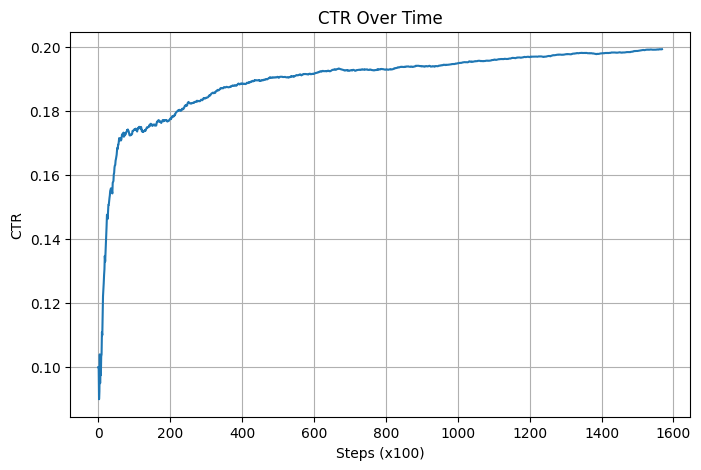

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(ctr_list)
plt.title("CTR Over Time")
plt.xlabel("Steps (x100)")
plt.ylabel("CTR")
plt.grid()
plt.show()

In [ ]:
import numpy as np

def compute_auc(labels, scores):
    labels = np.array(labels)
    scores = np.array(scores)

    pos = scores[labels == 1]
    neg = scores[labels == 0]

    if len(pos) == 0 or len(neg) == 0:
        return None

    total = 0
    correct = 0

    for p in pos:
        for n in neg:
            total += 1
            if p > n:
                correct += 1
            elif p == n:
                correct += 0.5

    return correct / total


def compute_mrr(labels, scores):
    order = np.argsort(scores)[::-1]

    for rank, idx in enumerate(order):
        if labels[idx] == 1:
            return 1.0 / (rank + 1)

    return 0.0


def compute_dcg(labels, scores, k):
    order = np.argsort(scores)[::-1][:k]

    dcg = 0.0
    for i, idx in enumerate(order):
        if labels[idx] == 1:
            dcg += 1 / np.log2(i + 2)

    return dcg


def compute_ndcg(labels, scores, k):
    dcg = compute_dcg(labels, scores, k)

    ideal_labels = sorted(labels, reverse=True)
    ideal_dcg = compute_dcg(ideal_labels, ideal_labels, k)

    if ideal_dcg == 0:
        return 0.0

    return dcg / ideal_dcg

In [ ]:
auc_list = []
mrr_list = []
ndcg5_list = []
ndcg10_list = []

for idx, row in behaviors.iterrows():

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = row["impressions"]

    X_candidates = []
    labels = []

    for news_id, label in impressions:
        vec = news_vector_dict.get(news_id)
        if vec is None:
            continue

        feature = np.empty(d, dtype=np.float32)
        feature[:user_dim] = user_vec
        feature[user_dim:] = vec

        X_candidates.append(feature)
        labels.append(label)

    if len(X_candidates) == 0:
        continue

    X_candidates = np.array(X_candidates)
    labels = np.array(labels)

    # Get scores (not just argmax)
    theta = bandit.A_inv @ bandit.b
    scores = X_candidates @ theta

    # Metrics
    auc = compute_auc(labels, scores)
    if auc is not None:
        auc_list.append(auc)

    mrr_list.append(compute_mrr(labels, scores))
    ndcg5_list.append(compute_ndcg(labels, scores, 5))
    ndcg10_list.append(compute_ndcg(labels, scores, 10))

In [ ]:
print("===== Evaluation Results =====")
print("Mean AUC:", np.mean(auc_list))
print("Mean MRR:", np.mean(mrr_list))
print("Mean nDCG@5:", np.mean(ndcg5_list))
print("Mean nDCG@10:", np.mean(ndcg10_list))

===== Evaluation Results =====
Mean AUC: 0.5813964753203403
Mean MRR: 0.3457675185723725
Mean nDCG@5: 0.313423820134974
Mean nDCG@10: 0.3660423827794855


# Thomsom Sampling

In [ ]:
import numpy as np

class FastThompsonSampling:
    def __init__(self, d, v=0.1):
        self.d = d
        self.v = v

        self.A = np.ones(d, dtype=np.float32)   # diagonal approx
        self.b = np.zeros(d, dtype=np.float32)

    def sample_theta(self):
        mu = self.b / self.A
        sigma = self.v / np.sqrt(self.A)

        theta = np.random.normal(mu, sigma)
        return theta

    def select(self, X):
        theta = self.sample_theta()
        return np.argmax(X @ theta)

    def update(self, x, reward):
        self.A += x * x
        self.b += reward * x

In [ ]:
from tqdm import tqdm

bandit_ts = FastThompsonSampling(d, v=0.1)

rewards_ts = []

for idx in tqdm(range(len(behaviors_fast))):

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors_fast.iloc[idx]["impressions"][:10]

    X = []
    y = []

    for news_id, label in impressions:
        vec = news_vector_dict.get(news_id)
        if vec is None:
            continue

        feature = np.empty(d, dtype=np.float32)
        feature[:user_dim] = user_vec
        feature[user_dim:] = vec

        X.append(feature)
        y.append(label)

    if not X:
        continue

    X = np.array(X)
    y = np.array(y)

    chosen = bandit_ts.select(X)
    reward = y[chosen]

    bandit_ts.update(X[chosen], reward)
    rewards_ts.append(reward)

print("Fast TS CTR:", np.mean(rewards_ts))

100%|██████████| 10000/10000 [00:05<00:00, 1997.22it/s]

Fast TS CTR: 0.1359


In [ ]:
def fast_mrr(labels, scores):
    order = np.argsort(scores)[::-1]
    for i, idx in enumerate(order):
        if labels[idx] == 1:
            return 1.0 / (i + 1)
    return 0.0


def fast_ndcg(labels, scores, k):
    order = np.argsort(scores)[::-1][:k]

    dcg = 0.0
    for i, idx in enumerate(order):
        if labels[idx] == 1:
            dcg += 1 / np.log2(i + 2)

    ideal_hits = sum(labels)
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, ideal_hits))])

    return dcg / idcg if idcg > 0 else 0.0


def fast_auc(labels, scores):
    labels = np.array(labels)
    scores = np.array(scores)

    pos = scores[labels == 1]
    neg = scores[labels == 0]

    if len(pos) == 0 or len(neg) == 0:
        return None

    # Vectorized comparison
    comparisons = (pos[:, None] > neg).mean()
    ties = (pos[:, None] == neg).mean() * 0.5

    return comparisons + ties

In [ ]:
mrr_list = []
ndcg5_list = []
ndcg10_list = []
auc_list = []

# 🔥 Get model parameters ONCE
mu = bandit_ts.b / bandit_ts.A   # diagonal TS

for idx in range(len(behaviors_fast)):

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors_fast.iloc[idx]["impressions"][:10]

    X = []
    y = []

    for news_id, label in impressions:
        vec = news_vector_dict.get(news_id)
        if vec is None:
            continue

        feature = np.empty(d, dtype=np.float32)
        feature[:user_dim] = user_vec
        feature[user_dim:] = vec

        X.append(feature)
        y.append(label)

    if not X:
        continue

    X = np.array(X)
    y = np.array(y)

    # 🔥 FAST scoring
    scores = X @ mu

    # Metrics
    mrr_list.append(fast_mrr(y, scores))
    ndcg5_list.append(fast_ndcg(y, scores, 5))
    ndcg10_list.append(fast_ndcg(y, scores, 10))

    auc = fast_auc(y, scores)
    if auc is not None:
        auc_list.append(auc)

In [ ]:
print("===== Thompson Sampling Results =====")
print("CTR:", np.mean(rewards_ts))
print("Mean AUC:", np.mean(auc_list))
print("Mean MRR:", np.mean(mrr_list))
print("Mean nDCG@5:", np.mean(ndcg5_list))
print("Mean nDCG@10:", np.mean(ndcg10_list))

===== Thompson Sampling Results =====
CTR: 0.1359
Mean AUC: 0.5423517273737025
Mean MRR: 0.25816055555555556
Mean nDCG@5: 0.2746603580134577
Mean nDCG@10: 0.3327670811676903


In [ ]:
class FastThompsonSampling:
    def __init__(self, d, v=0.3):   # 🔥 increased exploration
        self.d = d
        self.v = v

        self.A = np.ones(d, dtype=np.float32)
        self.b = np.zeros(d, dtype=np.float32)

    def sample_theta(self):
        mu = self.b / self.A
        sigma = self.v / np.sqrt(self.A)
        return np.random.normal(mu, sigma)

    def select(self, X):
        theta = self.sample_theta()
        return np.argmax(X @ theta)

    def update(self, x, reward):
        self.A += x * x
        self.b += reward * x

In [ ]:
bandit_ts = FastThompsonSampling(d, v=0.3)

rewards_ts = []

for idx in range(len(behaviors_fast)):

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors_fast.iloc[idx]["impressions"][:20]  # 🔥 increased

    X = []
    y = []

    for news_id, label in impressions:
        vec = news_vector_dict.get(news_id)
        if vec is None:
            continue

        feature = np.empty(d, dtype=np.float32)
        feature[:user_dim] = user_vec
        feature[user_dim:] = vec

        X.append(feature)
        y.append(label)

    if not X:
        continue

    X = np.array(X)
    y = np.array(y)

    # 🔥 hybrid exploration (small noise)
    theta = bandit_ts.sample_theta()
    scores = X @ theta + 0.01 * np.random.randn(len(X))

    chosen = np.argmax(scores)
    reward = y[chosen]

    bandit_ts.update(X[chosen], reward)
    rewards_ts.append(reward)

print("Improved CTR:", np.mean(rewards_ts))

Improved CTR: 0.1391


In [ ]:
def fast_auc(labels, scores):
    labels = np.array(labels)
    scores = np.array(scores)

    pos = scores[labels == 1]
    neg = scores[labels == 0]

    if len(pos) == 0 or len(neg) == 0:
        return None

    # Vectorized pairwise comparison
    comparisons = (pos[:, None] > neg).mean()
    ties = (pos[:, None] == neg).mean() * 0.5

    return comparisons + ties

In [ ]:
auc_list = []
mrr_list = []
ndcg5_list = []
ndcg10_list = []

mu = bandit_ts.b / bandit_ts.A   # fast TS estimate

for idx in range(len(behaviors_fast)):

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors_fast.iloc[idx]["impressions"][:20]

    X, y = [], []

    for news_id, label in impressions:
        vec = news_vector_dict.get(news_id)
        if vec is None:
            continue

        feature = np.empty(d, dtype=np.float32)
        feature[:user_dim] = user_vec
        feature[user_dim:] = vec

        X.append(feature)
        y.append(label)

    if not X:
        continue

    X = np.array(X)
    y = np.array(y)

    scores = X @ mu

    # ✅ AUC
    auc = fast_auc(y, scores)
    if auc is not None:
        auc_list.append(auc)

    # Other metrics
    mrr_list.append(fast_mrr(y, scores))
    ndcg5_list.append(fast_ndcg(y, scores, 5))
    ndcg10_list.append(fast_ndcg(y, scores, 10))

In [ ]:
print("===== Improved Thompson Results =====")
print("CTR:", np.mean(rewards_ts))
print("AUC:", np.mean(auc_list))
print("MRR:", np.mean(mrr_list))
print("nDCG@5:", np.mean(ndcg5_list))
print("nDCG@10:", np.mean(ndcg10_list))

===== Improved Thompson Results =====
CTR: 0.1391
AUC: 0.5328607820687684
MRR: 0.2753343842071242
nDCG@5: 0.2695836313358533
nDCG@10: 0.3290574402002272


# optimization

In [ ]:
import numpy as np

class FastHybridLinUCB:
    def __init__(self, d_user, d_news, alpha=1.0):
        self.alpha = alpha

        self.d_user = d_user
        self.d_news = d_news

        # Shared
        self.A0 = np.eye(d_user, dtype=np.float32)
        self.A0_inv = np.eye(d_user, dtype=np.float32)
        self.b0 = np.zeros(d_user, dtype=np.float32)

        # Action-specific
        self.A = np.eye(d_news, dtype=np.float32)
        self.A_inv = np.eye(d_news, dtype=np.float32)
        self.b = np.zeros(d_news, dtype=np.float32)

    def select(self, user_vec, X_news):
        # Compute beta once
        beta = self.A0_inv @ self.b0

        # Vectorized mean
        mean = X_news @ self.b + beta @ user_vec

        # Fast uncertainty (approx)
        u_user = np.sqrt(user_vec @ self.A0_inv @ user_vec)
        u_news = np.sqrt(np.sum(X_news @ self.A_inv * X_news, axis=1))

        scores = mean + self.alpha * (u_user + u_news)

        return np.argmax(scores)

    def update(self, user_vec, news_vec, reward):
        # --- Update user part (Sherman-Morrison) ---
        u = user_vec.reshape(-1, 1)
        Au = self.A0_inv @ u
        self.A0_inv -= (Au @ Au.T) / (1 + u.T @ Au)

        self.b0 += reward * user_vec

        # --- Update news part ---
        x = news_vec.reshape(-1, 1)
        Ax = self.A_inv @ x
        self.A_inv -= (Ax @ Ax.T) / (1 + x.T @ Ax)

        self.b += reward * news_vec

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [ ]:
from tqdm import tqdm
import numpy as np

bandit = FastHybridLinUCB(d_user, d_news, alpha=1.0)

rewards = []

for idx in tqdm(range(len(behaviors))):

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors.iloc[idx]["impressions"][:20]  # limit

    # Preallocate
    news_vecs = []
    labels = []

    for news_id, label in impressions:
        vec = news_vector_dict.get(news_id)
        if vec is None:
            continue

        news_vecs.append(vec.astype(np.float32))
        labels.append(label)

    if not news_vecs:
        continue

    X_news = np.stack(news_vecs)
    labels = np.array(labels, dtype=np.int8)

    # FAST selection
    chosen = bandit.select(user_vec, X_news)
    reward = labels[chosen]

    # Update
    bandit.update(user_vec, X_news[chosen], reward)

    rewards.append(reward)

print("Fast Hybrid CTR:", np.mean(rewards))

100%|██████████| 156965/156965 [30:59<00:00, 84.39it/s] 

Fast Hybrid CTR: 0.12253050043003218


In [ ]:
def fast_mrr(labels, scores):
    order = np.argsort(scores)[::-1]
    for i, idx in enumerate(order):
        if labels[idx] == 1:
            return 1.0 / (i + 1)
    return 0.0


def fast_ndcg(labels, scores, k):
    order = np.argsort(scores)[::-1][:k]

    dcg = sum([1 / np.log2(i + 2) for i, idx in enumerate(order) if labels[idx] == 1])

    ideal_hits = sum(labels)
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, ideal_hits))])

    return dcg / idcg if idcg > 0 else 0.0


def fast_auc(labels, scores):
    labels = np.array(labels)
    scores = np.array(scores)

    pos = scores[labels == 1]
    neg = scores[labels == 0]

    if len(pos) == 0 or len(neg) == 0:
        return None

    comparisons = (pos[:, None] > neg).mean()
    ties = (pos[:, None] == neg).mean() * 0.5

    return comparisons + ties

In [ ]:
auc_list = []
mrr_list = []
ndcg5_list = []
ndcg10_list = []

# Precompute shared parameter
beta = bandit.A0_inv @ bandit.b0

for idx in range(len(behaviors)):

    user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors.iloc[idx]["impressions"][:20]

    news_vecs = []
    labels = []

    for news_id, label in impressions:
        vec = news_vector_dict.get(news_id)
        if vec is None:
            continue

        news_vecs.append(vec.astype(np.float32))
        labels.append(label)

    if not news_vecs:
        continue

    X_news = np.stack(news_vecs)
    labels = np.array(labels)

    # 🔥 FAST scoring (vectorized)
    scores = X_news @ bandit.b + beta @ user_vec

    # Metrics
    auc = fast_auc(labels, scores)
    if auc is not None:
        auc_list.append(auc)

    mrr_list.append(fast_mrr(labels, scores))
    ndcg5_list.append(fast_ndcg(labels, scores, 5))
    ndcg10_list.append(fast_ndcg(labels, scores, 10))

In [ ]:
print("===== Hybrid LinUCB Results =====")
print("CTR:", np.mean(rewards))
print("AUC:", np.mean(auc_list))
print("MRR:", np.mean(mrr_list))
print("nDCG@5:", np.mean(ndcg5_list))
print("nDCG@10:", np.mean(ndcg10_list))

===== Hybrid LinUCB Results =====
CTR: 0.12253050043003218
AUC: 0.5204954918738974
MRR: 0.25891789618403654
nDCG@5: 0.25312738178223076
nDCG@10: 0.3157750800288794


### Hyperparameter Optimization with Optuna

To optimize the hyperparameters, we'll use the `Optuna` library. This will allow us to systematically search for the best `alpha` value for the bandit and the optimal `bottleneck_dim` for the feature projections.

In [ ]:
# Install Optuna (if not already installed)
!pip install optuna

import optuna
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm

# Re-import or define FastHybridLinUCB if it's not globally available
# (To ensure the objective function can run independently)
class FastHybridLinUCB:
    def __init__(self, d_user, d_news, alpha=1.0):
        self.alpha = alpha
        self.d_user = d_user
        self.d_news = d_news
        self.A0 = np.eye(d_user, dtype=np.float32)
        self.A0_inv = np.eye(d_user, dtype=np.float32)
        self.b0 = np.zeros(d_user, dtype=np.float32)
        self.A = np.eye(d_news, dtype=np.float32)
        self.A_inv = np.eye(d_news, dtype=np.float32)
        self.b = np.zeros(d_news, dtype=np.float32)

    def select(self, user_vec, X_news):
        beta = self.A0_inv @ self.b0
        mean = X_news @ self.b + beta @ user_vec
        u_user = np.sqrt(user_vec @ self.A0_inv @ user_vec)
        u_news = np.sqrt(np.sum(X_news @ self.A_inv * X_news, axis=1))
        scores = mean + self.alpha * (u_user + u_news)
        return np.argmax(scores)

    def update(self, user_vec, news_vec, reward):
        u = user_vec.reshape(-1, 1)
        Au = self.A0_inv @ u
        self.A0_inv -= (Au @ Au.T) / (1 + u.T @ Au)
        self.b0 += reward * user_vec
        x = news_vec.reshape(-1, 1)
        Ax = self.A_inv @ x
        self.A_inv -= (Ax @ Ax.T) / (1 + x.T @ Ax)
        self.b += reward * news_vec

# Also re-define the evaluation metrics if they are not in a globally accessible cell
def fast_auc(labels, scores):
    labels = np.array(labels)
    scores = np.array(scores)
    pos = scores[labels == 1]
    neg = scores[labels == 0]
    if len(pos) == 0 or len(neg) == 0:
        return None
    comparisons = (pos[:, None] > neg).mean()
    ties = (pos[:, None] == neg).mean() * 0.5
    return comparisons + ties

def fast_mrr(labels, scores):
    order = np.argsort(scores)[::-1]
    for i, idx in enumerate(order):
        if labels[idx] == 1:
            return 1.0 / (i + 1)
    return 0.0

def fast_ndcg(labels, scores, k):
    order = np.argsort(scores)[::-1][:k]
    dcg = sum([1 / np.log2(i + 2) for i, idx in enumerate(order) if labels[idx] == 1])
    ideal_hits = sum(labels)
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, ideal_hits))])
    return dcg / idcg if idcg > 0 else 0.0


# Load data to ensure it's available within the objective function's scope
# (Assuming these were loaded in previous cells, but re-loading for robustness in Optuna trials)
base_path = "/content/drive/MyDrive//Colab Notebooks/"
behaviors = pd.read_pickle(base_path + "behaviors_clean.pkl")
user_vectors = np.load(base_path + "user_vectors.npy")
with open(base_path + "news_vector_dict.pkl", "rb") as f:
    news_vector_dict = pickle.load(f)

original_user_dim = user_vectors.shape[1]
original_news_dim = len(next(iter(news_vector_dict.values())))


def objective(trial):
    # Hyperparameters to tune
    alpha = trial.suggest_float('alpha', 0.1, 5.0, log=True)
    bottleneck_dim = trial.suggest_int('bottleneck_dim', 32, 256, step=32)

    # Generate fixed random projection matrices based on trial's bottleneck_dim
    np.random.seed(42) # for reproducibility
    W_user_proj = np.random.randn(original_user_dim, bottleneck_dim).astype(np.float32) / np.sqrt(original_user_dim)
    W_news_proj = np.random.randn(original_news_dim, bottleneck_dim).astype(np.float32) / np.sqrt(original_news_dim)

    # Instantiate FastHybridLinUCB with trial's bottleneck_dim and alpha
    bandit_bottleneck = FastHybridLinUCB(d_user=bottleneck_dim, d_news=bottleneck_dim, alpha=alpha)

    rewards_bottleneck = []

    # Limit the number of behaviors for faster hyperparameter search
    # For a full run, you'd use len(behaviors)
    n_trials_data_limit = 5000  # Adjust this for faster or more accurate trials

    for idx in range(min(len(behaviors), n_trials_data_limit)):
        original_user_vec = user_vectors[idx].astype(np.float32)
        impressions = behaviors.iloc[idx]["impressions"][:20]

        user_vec_proj = original_user_vec @ W_user_proj
        news_vecs_proj = []
        labels = []

        for news_id, label in impressions:
            original_news_vec = news_vector_dict.get(news_id)
            if original_news_vec is None:
                continue
            news_vec_proj = original_news_vec.astype(np.float32) @ W_news_proj
            news_vecs_proj.append(news_vec_proj)
            labels.append(label)

        if not news_vecs_proj:
            continue

        X_news_proj = np.stack(news_vecs_proj)
        labels = np.array(labels, dtype=np.int8)

        chosen = bandit_bottleneck.select(user_vec_proj, X_news_proj)
        reward = labels[chosen]
        bandit_bottleneck.update(user_vec_proj, X_news_proj[chosen], reward)
        rewards_bottleneck.append(reward)

    # Evaluate the model on the collected data subset
    # For simplicity, we will use CTR as the objective to maximize.
    # You could also compute AUC, MRR, etc., but it would require another loop through behaviors
    # or storing more intermediate states.

    # To calculate AUC/MRR/nDCG for evaluation, we'd need to re-run the prediction loop without updates
    # for the entire dataset or a validation set, which is more involved for an objective.
    # For now, let's use CTR as a proxy.

    # For a more robust objective, one would typically use a separate validation set
    # and re-evaluate metrics like AUC on that set after training the bandit.
    # Here, we will simplify and use the CTR from the training process as the objective.
    return np.mean(rewards_bottleneck) if rewards_bottleneck else 0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 325.3 kB/s eta 0:00:00


In [ ]:
# Create an Optuna study and optimize the objective function
# We aim to maximize the CTR (or whatever metric objective() returns)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # You can adjust n_trials for more thorough search

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-04-16 23:09:21,427] A new study created in memory with name: no-name-d9ee08fb-042c-4216-89b7-49cd53e25f60
[I 2026-04-16 23:09:27,901] Trial 0 finished with value: 0.1232 and parameters: {'alpha': 0.2106916729824529, 'bottleneck_dim': 128}. Best is trial 0 with value: 0.1232.
[I 2026-04-16 23:09:31,012] Trial 1 finished with value: 0.123 and parameters: {'alpha': 0.16475468392710907, 'bottleneck_dim': 32}. Best is trial 0 with value: 0.1232.
[I 2026-04-16 23:09:40,854] Trial 2 finished with value: 0.129 and parameters: {'alpha': 3.1777832031661912, 'bottleneck_dim': 224}. Best is trial 2 with value: 0.129.
[I 2026-04-16 23:09:42,668] Trial 3 finished with value: 0.1218 and parameters: {'alpha': 0.7674578313703976, 'bottleneck_dim': 32}. Best is trial 2 with value: 0.129.
[I 2026-04-16 23:09:54,399] Trial 4 finished with value: 0.1104 and parameters: {'alpha': 1.5632208332895972, 'bottleneck_dim': 256}. Best is trial 2 with value: 0.129.
[I 2026-04-16 23:09:56,263] Trial 5 finish

Number of finished trials:  50
Best trial:
  Value:  0.129
  Params: 
    alpha: 3.1777832031661912
    bottleneck_dim: 224


### Retraining with Optimal Hyperparameters

In [ ]:
# Extract optimal hyperparameters
best_alpha = study.best_trial.params['alpha']
best_bottleneck_dim = study.best_trial.params['bottleneck_dim']

print(f"Optimal Alpha: {best_alpha}")
print(f"Optimal Bottleneck Dimension: {best_bottleneck_dim}")

# Re-generate projection matrices with the optimal bottleneck_dim
np.random.seed(42) # Ensure reproducibility
W_user_proj_optimal = np.random.randn(original_user_dim, best_bottleneck_dim).astype(np.float32) / np.sqrt(original_user_dim)
W_news_proj_optimal = np.random.randn(original_news_dim, best_bottleneck_dim).astype(np.float32) / np.sqrt(original_news_dim)

# Instantiate FastHybridLinUCB with optimal bottleneck dimensions and alpha
bandit_optimal = FastHybridLinUCB(d_user=best_bottleneck_dim, d_news=best_bottleneck_dim, alpha=best_alpha)

rewards_optimal = []

for idx in tqdm(range(len(behaviors))):

    original_user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors.iloc[idx]["impressions"][:20]  # Limit impressions as before

    # Project user vector using optimal matrix
    user_vec_proj_optimal = original_user_vec @ W_user_proj_optimal

    # Prepare news candidates and labels using optimal projected news vectors
    news_vecs_proj_optimal = []
    labels = []

    for news_id, label in impressions:
        original_news_vec = news_vector_dict.get(news_id)
        if original_news_vec is None:
            continue

        # Project news vector using optimal matrix
        news_vec_proj_optimal = original_news_vec.astype(np.float32) @ W_news_proj_optimal

        news_vecs_proj_optimal.append(news_vec_proj_optimal)
        labels.append(label)

    if not news_vecs_proj_optimal:
        continue

    X_news_proj_optimal = np.stack(news_vecs_proj_optimal)
    labels = np.array(labels, dtype=np.int8)

    # SELECT ACTION using the bandit on projected features
    chosen = bandit_optimal.select(user_vec_proj_optimal, X_news_proj_optimal)
    reward = labels[chosen]

    # UPDATE MODEL using the bandit on projected features
    bandit_optimal.update(user_vec_proj_optimal, X_news_proj_optimal[chosen], reward)

    rewards_optimal.append(reward)

print("Optimal Two-Tower Bottleneck LinUCB CTR:", np.mean(rewards_optimal))

Optimal Alpha: 3.1777832031661912
Optimal Bottleneck Dimension: 224


100%|██████████| 156965/156965 [05:45<00:00, 454.56it/s]

Optimal Two-Tower Bottleneck LinUCB CTR: 0.12419966234510878


### Evaluating the Optimized Model

In [ ]:
auc_list_optimal = []
mrr_list_optimal = []
ndcg5_list_optimal = []
ndcg10_list_optimal = []

# Precompute shared parameter for evaluation using the optimal bandit
beta_optimal = bandit_optimal.A0_inv @ bandit_optimal.b0

for idx in tqdm(range(len(behaviors))):

    original_user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors.iloc[idx]["impressions"][:20]

    # Project user vector using optimal matrix
    user_vec_proj_optimal = original_user_vec @ W_user_proj_optimal

    news_vecs_proj_optimal = []
    labels = []

    for news_id, label in impressions:
        original_news_vec = news_vector_dict.get(news_id)
        if original_news_vec is None:
            continue

        # Project news vector using optimal matrix
        news_vec_proj_optimal = original_news_vec.astype(np.float32) @ W_news_proj_optimal

        news_vecs_proj_optimal.append(news_vec_proj_optimal)
        labels.append(label)

    if not news_vecs_proj_optimal:
        continue

    X_news_proj_optimal = np.stack(news_vecs_proj_optimal)
    labels = np.array(labels)

    # FAST scoring (vectorized) with optimal projected features
    scores = X_news_proj_optimal @ bandit_optimal.b + beta_optimal @ user_vec_proj_optimal

    # Metrics
    auc = fast_auc(labels, scores)
    if auc is not None:
        auc_list_optimal.append(auc)

    mrr_list_optimal.append(fast_mrr(labels, scores))
    ndcg5_list_optimal.append(fast_ndcg(labels, scores, 5))
    ndcg10_list_optimal.append(fast_ndcg(labels, scores, 10))

100%|██████████| 156965/156965 [02:31<00:00, 1037.00it/s]


In [ ]:
print("===== Optimal Two-Tower Bottleneck LinUCB Results =====")
print("CTR:", np.mean(rewards_optimal))
print("AUC:", np.mean(auc_list_optimal))
print("MRR:", np.mean(mrr_list_optimal))
print("nDCG@5:", np.mean(ndcg5_list_optimal))
print("nDCG@10:", np.mean(ndcg10_list_optimal))

===== Optimal Two-Tower Bottleneck LinUCB Results =====
CTR: 0.12419966234510878
AUC: 0.5180451587436204
MRR: 0.258924112508296
nDCG@5: 0.2528541622430481
nDCG@10: 0.31503755614567813


### Two-Tower Bottleneck with Thompson Sampling

In [ ]:
import numpy as np

class FastThompsonSamplingBottleneck:
    def __init__(self, d_user, d_news, v=0.1):
        self.d_user = d_user
        self.d_news = d_news
        self.v = v

        # User tower parameters
        self.A_user = np.ones(d_user, dtype=np.float32)   # diagonal approx
        self.b_user = np.zeros(d_user, dtype=np.float32)

        # News tower parameters
        self.A_news = np.ones(d_news, dtype=np.float32)
        self.b_news = np.zeros(d_news, dtype=np.float32)

    def sample_theta(self):
        mu_user = self.b_user / self.A_user
        sigma_user = self.v / np.sqrt(self.A_user)
        theta_user = np.random.normal(mu_user, sigma_user)

        mu_news = self.b_news / self.A_news
        sigma_news = self.v / np.sqrt(self.A_news)
        theta_news = np.random.normal(mu_news, sigma_news)

        return theta_user, theta_news

    def select(self, user_vec_proj, X_news_proj):
        theta_user, theta_news = self.sample_theta()

        # Score is dot product of user feature with user theta and news feature with news theta
        # This assumes the interaction happens in the bottleneck space
        scores = (user_vec_proj @ theta_user) + (X_news_proj @ theta_news)

        return np.argmax(scores)

    def update(self, user_vec_proj, news_vec_proj, reward):
        # Update user tower
        self.A_user += user_vec_proj * user_vec_proj
        self.b_user += reward * user_vec_proj

        # Update news tower
        self.A_news += news_vec_proj * news_vec_proj
        self.b_news += reward * news_vec_proj

In [ ]:
from tqdm import tqdm

# Instantiate FastThompsonSamplingBottleneck with bottleneck dimensions
bot_ts_bandit = FastThompsonSamplingBottleneck(d_user=bottleneck_dim, d_news=bottleneck_dim, v=0.1)

rewards_bot_ts = []

for idx in tqdm(range(len(behaviors))):

    original_user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors.iloc[idx]["impressions"][:20]  # Limit impressions for speed

    # Project user vector
    user_vec_proj = original_user_vec @ W_user_proj

    # Prepare news candidates and labels using projected news vectors
    news_vecs_proj = []
    labels = []

    for news_id, label in impressions:
        original_news_vec = news_vector_dict.get(news_id)
        if original_news_vec is None:
            continue

        # Project news vector
        news_vec_proj = original_news_vec.astype(np.float32) @ W_news_proj

        news_vecs_proj.append(news_vec_proj)
        labels.append(label)

    if not news_vecs_proj:
        continue

    X_news_proj = np.stack(news_vecs_proj)
    labels = np.array(labels, dtype=np.int8)

    # SELECT ACTION using the bandit on projected features
    chosen = bot_ts_bandit.select(user_vec_proj, X_news_proj)
    reward = labels[chosen]

    # UPDATE MODEL using the bandit on projected features
    bot_ts_bandit.update(user_vec_proj, X_news_proj[chosen], reward)

    rewards_bot_ts.append(reward)

print("Two-Tower Bottleneck Thompson Sampling CTR:", np.mean(rewards_bot_ts))

100%|██████████| 156965/156965 [01:50<00:00, 1415.86it/s]

Two-Tower Bottleneck Thompson Sampling CTR: 0.12459465485936355


### Evaluating Two-Tower Bottleneck Thompson Sampling Model

In [ ]:
auc_list_bot_ts = []
mrr_list_bot_ts = []
ndcg5_list_bot_ts = []
ndcg10_list_bot_ts = []

# Get the final estimated parameters (mean of the posterior) for evaluation
mu_user_eval = bot_ts_bandit.b_user / bot_ts_bandit.A_user
mu_news_eval = bot_ts_bandit.b_news / bot_ts_bandit.A_news

for idx in tqdm(range(len(behaviors))):

    original_user_vec = user_vectors[idx].astype(np.float32)
    impressions = behaviors.iloc[idx]["impressions"][:20]

    user_vec_proj = original_user_vec @ W_user_proj

    news_vecs_proj = []
    labels = []

    for news_id, label in impressions:
        original_news_vec = news_vector_dict.get(news_id)
        if original_news_vec is None:
            continue

        news_vec_proj = original_news_vec.astype(np.float32) @ W_news_proj

        news_vecs_proj.append(news_vec_proj)
        labels.append(label)

    if not news_vecs_proj:
        continue

    X_news_proj = np.stack(news_vecs_proj)
    labels = np.array(labels)

    # Scores using the mean of the posterior for evaluation
    scores = (user_vec_proj @ mu_user_eval) + (X_news_proj @ mu_news_eval)

    auc = fast_auc(labels, scores)
    if auc is not None:
        auc_list_bot_ts.append(auc)

    mrr_list_bot_ts.append(fast_mrr(labels, scores))
    ndcg5_list_bot_ts.append(fast_ndcg(labels, scores, 5))
    ndcg10_list_bot_ts.append(fast_ndcg(labels, scores, 10))

100%|██████████| 156965/156965 [01:52<00:00, 1395.01it/s]


In [ ]:
print("===== Two-Tower Bottleneck Thompson Sampling Results =====")
print("CTR:", np.mean(rewards_bot_ts))
print("AUC:", np.mean(auc_list_bot_ts))
print("MRR:", np.mean(mrr_list_bot_ts))
print("nDCG@5:", np.mean(ndcg5_list_bot_ts))
print("nDCG@10:", np.mean(ndcg10_list_bot_ts))

===== Two-Tower Bottleneck Thompson Sampling Results =====
CTR: 0.12459465485936355
AUC: 0.526239038190898
MRR: 0.2620879420909902
nDCG@5: 0.2572545654313628
nDCG@10: 0.3187859518305435


# Disjoint LinUCB

In [2]:
class FastDisjointLinUCB:
    def __init__(self, d, alpha=1.0):
        self.d = d
        self.alpha = alpha
        # Dictionary to store per-category models
        self.models = {}

    def _get_model(self, category_id):
        if category_id not in self.models:
            self.models[category_id] = {
                'A_inv': np.eye(self.d, dtype=np.float32),
                'b': np.zeros(self.d, dtype=np.float32)
            }
        return self.models[category_id]

    def select(self, X, categories):
        scores = []
        for i in range(len(X)):
            model = self._get_model(categories[i])
            theta = model['A_inv'] @ model['b']
            mean = X[i] @ theta
            uncertainty = self.alpha * np.sqrt(X[i] @ model['A_inv'] @ X[i])
            scores.append(mean + uncertainty)
        return np.argmax(scores)

    def update(self, x, category_id, reward):
        model = self._get_model(category_id)
        x = x.reshape(-1, 1)
        Ax = model['A_inv'] @ x
        model['A_inv'] -= (Ax @ Ax.T) / (1 + (x.T @ Ax))
        model['b'] += reward * x.flatten()

In [4]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import pickle

# Ensure data is loaded
# base_path = "/content/drive/MyDrive//Colab Notebooks/"
behaviors = pd.read_pickle(base_path + "behaviors_clean.pkl")
user_vectors = np.load(base_path + "user_vectors.npy")
with open(base_path + "news_vector_dict.pkl", "rb") as f:
    news_vector_dict = pickle.load(f)

# Define target dimension
pca_dim = 128

# Fit PCA on user vectors
pca_user = PCA(n_components=pca_dim)
user_vectors_pca = pca_user.fit_transform(user_vectors).astype(np.float32)

# Fit PCA on news vectors
news_ids = list(news_vector_dict.keys())
news_matrix = np.array([news_vector_dict[nid] for nid in news_ids])

pca_news = PCA(n_components=pca_dim)
news_matrix_pca = pca_news.fit_transform(news_matrix).astype(np.float32)

# Update the dictionary with reduced vectors
news_vector_dict_pca = {nid: vec for nid, vec in zip(news_ids, news_matrix_pca)}

print(f"User PCA Explained Variance: {sum(pca_user.explained_variance_ratio_):.4f}")
print(f"News PCA Explained Variance: {sum(pca_news.explained_variance_ratio_):.4f}")

User PCA Explained Variance: 0.9786
News PCA Explained Variance: 0.7770


In [6]:
d_pca = pca_dim * 2


In [8]:
import pickle
from tqdm import tqdm

# Load news-to-category mapping
with open(base_path + 'news_category_dict.pkl', 'rb') as f:
    news_category_dict = pickle.load(f)

# Re-run Disjoint LinUCB simulation with correct category mapping
disjoint_bandit = FastDisjointLinUCB(d_pca, alpha=0.0543)
rewards_disjoint = []

print('Running Disjoint LinUCB simulation...')
for idx in tqdm(range(len(behaviors))):
    u_vec = user_vectors_pca[idx]
    row = behaviors.iloc[idx]
    imps = row['impressions']

    X, y, cats = [], [], []
    for nid, label in imps:
        n_vec = news_vector_dict_pca.get(nid)
        cat_raw = news_category_dict.get(nid)
        if n_vec is None or cat_raw is None: continue

        # Convert numpy array to tuple to make it hashable for the bandit dictionary
        cat_id = tuple(cat_raw.tolist())

        X.append(np.concatenate([u_vec, n_vec]))
        y.append(label)
        cats.append(cat_id)

    if not X: continue
    X = np.stack(X)

    chosen_idx = disjoint_bandit.select(X, cats)
    reward = y[chosen_idx]
    disjoint_bandit.update(X[chosen_idx], cats[chosen_idx], reward)
    rewards_disjoint.append(reward)

print(f'\nDisjoint LinUCB CTR: {np.mean(rewards_disjoint):.4f}')

Running Disjoint LinUCB simulation...


100%|██████████| 156965/156965 [02:47<00:00, 938.02it/s] 


Disjoint LinUCB CTR: 0.2289


In [9]:
rewards_array = np.array(rewards_disjoint)

# Cumulative CTR
ctr_curve = np.cumsum(rewards_array) / (np.arange(len(rewards_array)) + 1)

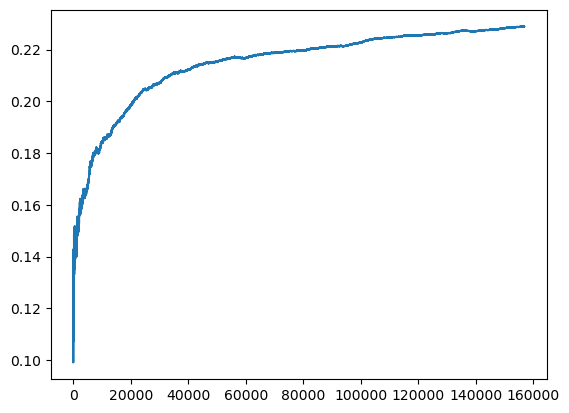

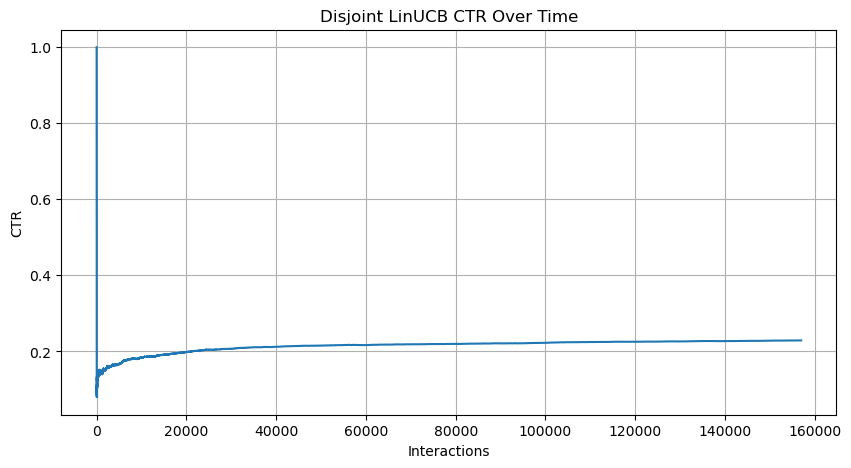

In [15]:
start = 100  # ignore first 100 interactions

plt.plot(ctr_curve[start:], label="Cumulative CTR")
plt.figure(figsize=(10, 5))
plt.plot(ctr_curve)
plt.xlabel("Interactions")
plt.ylabel("CTR")
plt.title("Disjoint LinUCB CTR Over Time")
plt.grid()
plt.show()

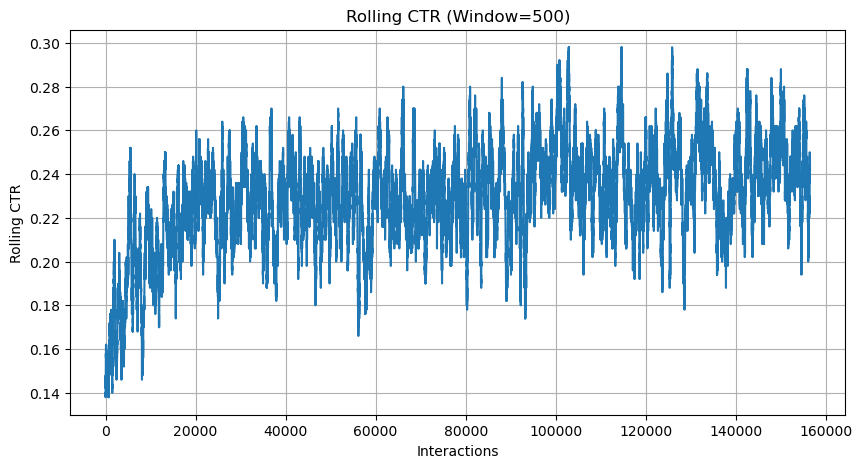

In [11]:
window = 500
rolling_ctr = np.convolve(
    rewards_array,
    np.ones(window)/window,
    mode='valid'
)

plt.figure(figsize=(10,5))
plt.plot(rolling_ctr)
plt.xlabel("Interactions")
plt.ylabel("Rolling CTR")
plt.title("Rolling CTR (Window=500)")
plt.grid()
plt.show()

In [12]:
smooth_window = 200

rolling_ctr_smooth = np.convolve(
    rolling_ctr,
    np.ones(smooth_window) / smooth_window,
    mode='valid'
)

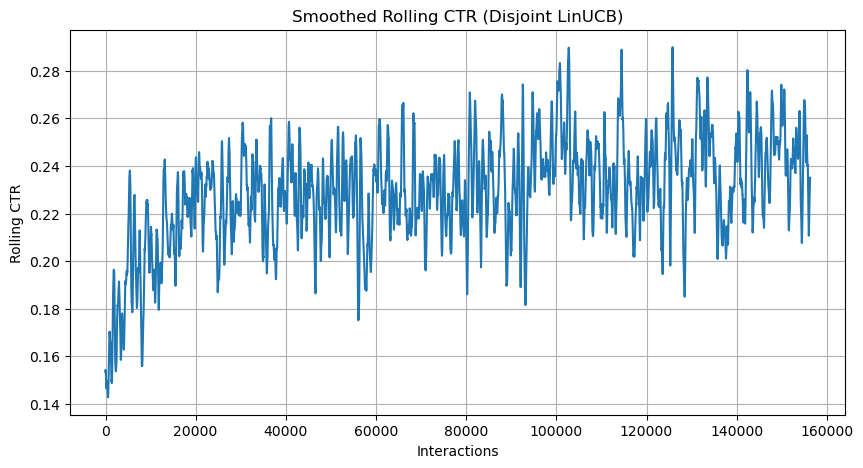

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rolling_ctr_smooth)

plt.xlabel("Interactions")
plt.ylabel("Rolling CTR")
plt.title("Smoothed Rolling CTR (Disjoint LinUCB)")
plt.grid()

plt.show()

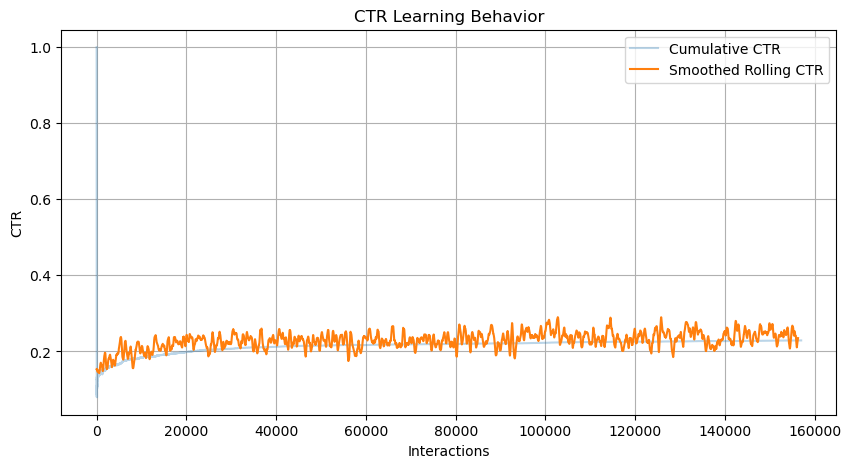

In [14]:
plt.figure(figsize=(10, 5))

# cumulative CTR
ctr_curve = np.cumsum(rewards_array) / (np.arange(len(rewards_array)) + 1)
plt.plot(ctr_curve, alpha=0.3, label="Cumulative CTR")

# rolling CTR
plt.plot(rolling_ctr_smooth, label="Smoothed Rolling CTR")

plt.xlabel("Interactions")
plt.ylabel("CTR")
plt.title("CTR Learning Behavior")
plt.legend()
plt.grid()

plt.show()

In [17]:
def fast_mrr(labels, scores):
    order = np.argsort(scores)[::-1]
    for i, idx in enumerate(order):
        if labels[idx] == 1:
            return 1.0 / (i + 1)
    return 0.0

def fast_ndcg(labels, scores, k):
    order = np.argsort(scores)[::-1][:k]
    dcg = sum([1 / np.log2(i + 2) for i, idx in enumerate(order) if labels[idx] == 1])
    ideal_hits = sum(labels)
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, ideal_hits))])
    return dcg / idcg if idcg > 0 else 0.0

def fast_auc(labels, scores):
    labels = np.array(labels)
    scores = np.array(scores)
    pos = scores[labels == 1]
    neg = scores[labels == 0]
    if len(pos) == 0 or len(neg) == 0:
        return None
    comparisons = (pos[:, None] > neg).mean()
    ties = (pos[:, None] == neg).mean() * 0.5
    return comparisons + ties


In [18]:
# Evaluation for Disjoint LinUCB
metrics_disjoint = {'auc': [], 'mrr': [], 'ndcg5': [], 'ndcg10': []}

from tqdm import tqdm
import numpy as np

print('Evaluating Disjoint LinUCB on full dataset...')
for idx in tqdm(range(len(behaviors))):
    u_vec = user_vectors_pca[idx]
    row = behaviors.iloc[idx]
    imps = row['impressions']

    X, y, cats = [], [], []
    for nid, label in imps:
        n_vec = news_vector_dict_pca.get(nid)
        cat_raw = news_category_dict.get(nid)
        if n_vec is None or cat_raw is None: continue

        cat_id = tuple(cat_raw.tolist())
        X.append(np.concatenate([u_vec, n_vec]))
        y.append(label)
        cats.append(cat_id)

    if not X: continue
    X = np.stack(X)
    y = np.array(y)

    # Scoring based on per-category models
    scores_disjoint = []
    for i in range(len(X)):
        model = disjoint_bandit._get_model(cats[i])
        theta = model['A_inv'] @ model['b']
        scores_disjoint.append(X[i] @ theta)

    scores_disjoint = np.array(scores_disjoint)

    # Metrics
    auc_d = fast_auc(y, scores_disjoint)
    if auc_d is not None: metrics_disjoint['auc'].append(auc_d)
    metrics_disjoint['mrr'].append(fast_mrr(y, scores_disjoint))
    metrics_disjoint['ndcg5'].append(fast_ndcg(y, scores_disjoint, 5))
    metrics_disjoint['ndcg10'].append(fast_ndcg(y, scores_disjoint, 10))

print("\n===== Disjoint LinUCB Evaluation Results =====")
print(f"Mean AUC:     {np.mean(metrics_disjoint['auc']):.4f}")
print(f"Mean MRR:     {np.mean(metrics_disjoint['mrr']):.4f}")
print(f"Mean nDCG@5:  {np.mean(metrics_disjoint['ndcg5']):.4f}")
print(f"Mean nDCG@10: {np.mean(metrics_disjoint['ndcg10']):.4f}")

Evaluating Disjoint LinUCB on full dataset...


100%|██████████| 156965/156965 [02:15<00:00, 1158.82it/s]


===== Disjoint LinUCB Evaluation Results =====
Mean AUC:     0.6173
Mean MRR:     0.3833
Mean nDCG@5:  0.3490
Mean nDCG@10: 0.4007


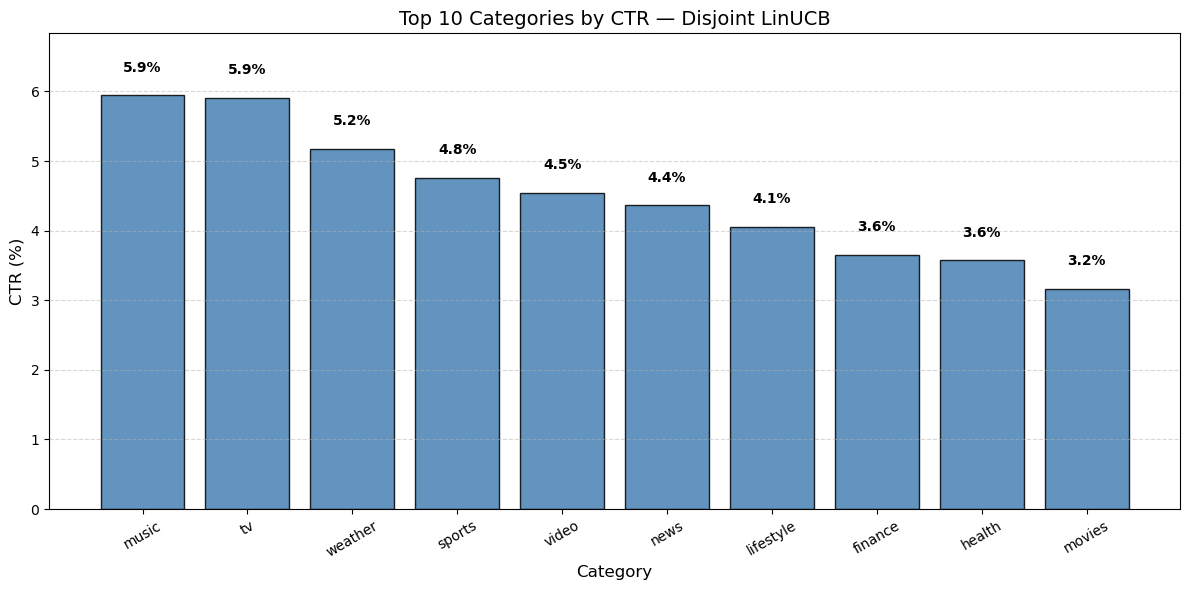

Top 10 Category CTRs:
  music                CTR: 5.94%  (n=269,008)
  tv                   CTR: 5.90%  (n=246,462)
  weather              CTR: 5.17%  (n=88,646)
  sports               CTR: 4.76%  (n=592,226)
  video                CTR: 4.55%  (n=93,744)
  news                 CTR: 4.36%  (n=1,591,038)
  lifestyle            CTR: 4.06%  (n=655,440)
  finance              CTR: 3.65%  (n=564,671)
  health               CTR: 3.57%  (n=304,088)
  movies               CTR: 3.17%  (n=132,091)


In [21]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build news_id -> category name mapping from news_clean.csv
news_meta = pd.read_csv(base_path + "news_clean.csv", usecols=["news_id", "category"])
news_category_name = dict(zip(news_meta["news_id"], news_meta["category"]))

# Track per-category clicks and total impressions
category_clicks = defaultdict(int)
category_impressions = defaultdict(int)

for idx in range(len(behaviors)):
    row = behaviors.iloc[idx]
    for nid, label in row["impressions"]:
        cat_name = news_category_name.get(nid)
        if cat_name is None:
            continue
        category_impressions[cat_name] += 1
        category_clicks[cat_name] += label

# Compute CTR per category (min 50 impressions)
category_ctr = {
    cat: category_clicks[cat] / category_impressions[cat]
    for cat in category_impressions
    if category_impressions[cat] >= 50
}

# Top 10 by CTR
top10 = sorted(category_ctr.items(), key=lambda x: x[1], reverse=True)[:10]
labels, ctrs = zip(*top10)
ctr_pct = [c * 100 for c in ctrs]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(labels, ctr_pct, color="steelblue", edgecolor="black", alpha=0.85)

for bar, val in zip(bars, ctr_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("CTR (%)", fontsize=12)
ax.set_title("Top 10 Categories by CTR — Disjoint LinUCB", fontsize=14)
ax.set_ylim(0, max(ctr_pct) * 1.15)
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Top 10 Category CTRs:")
for cat, ctr in zip(labels, ctrs):
    print(f"  {cat:<20} CTR: {ctr*100:.2f}%  (n={category_impressions[cat]:,})")


In [22]:
import pickle
import os

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

# Save Disjoint LinUCB model
with open(os.path.join(save_dir, "disjoint_linucb.pkl"), "wb") as f:
    pickle.dump(disjoint_bandit, f)

# Save PCA transformers (needed to preprocess new inputs)
with open(os.path.join(save_dir, "pca_user.pkl"), "wb") as f:
    pickle.dump(pca_user, f)

with open(os.path.join(save_dir, "pca_news.pkl"), "wb") as f:
    pickle.dump(pca_news, f)

print("Saved:")
print(f"  {save_dir}/disjoint_linucb.pkl")
print(f"  {save_dir}/pca_user.pkl")
print(f"  {save_dir}/pca_news.pkl")
print(f"  Categories learned: {len(disjoint_bandit.models)}")


Saved:
  saved_models/disjoint_linucb.pkl
  saved_models/pca_user.pkl
  saved_models/pca_news.pkl
  Categories learned: 328
